# Agent-5: Interactive Choi Channel Widget

이 노트북은 qubit quantum channel을 시각화하는 local widget을 만든다. IBM Quantum 계정이나 backend access 없이 실행할 수 있다. 프로젝트의 공유 convention은 다음과 같다.

$$C_{\mathcal{E}} = \sum_{ij} |i\rangle\langle j| \otimes \mathcal{E}(|i\rangle\langle j|),$$

따라서 input system $A$가 첫 번째 tensor factor이고, trace preservation은 $\mathrm{Tr}_B(C_{\mathcal{E}})=I_A$로 확인한다. Trace-preserving qubit channel은 $\mathrm{Tr}(C_{\mathcal{E}})=d_{\rm in}=2$를 만족한다.

**Palette:** blue `#2563eb`, green `#16a34a`, orange `#f97316`, red `#dc2626`, purple `#7c3aed`, gray `#475569`.

In [1]:
import numpy as np

np.random.seed(42)

from widget_core import (
    CHANNEL_TYPES,
    apply_choi_channel,
    build_widget,
    compute_indicators,
    format_indicator_text,
    get_channel_choi,
    render_dashboard_figure,
)

CHANNEL_TYPES

('Depolarizing',
 'Amplitude damping',
 'Phase damping',
 'Bit flip',
 'Phase flip',
 'Pauli',
 'Unital',
 'Mix two channels')

## 1. Design Goals

이 widget의 목적은 빠른 교육용 feedback을 제공하는 것이다. 사용자가 channel parameter를 바꾸면 Choi matrix $C_{\mathcal{E}}$, Bloch sphere deformation, Choi eigenspectrum, Choi eigenvectors에서 복원한 eigenoperators $K_k$, scalar CP/TP indicator, process-fidelity 또는 Choi-overlap indicator를 즉시 볼 수 있다.

의존성은 의도적으로 NumPy, Matplotlib, ipywidgets만 사용한다. IBM Quantum account, backend access, Qiskit installation이 필요 없다.

## 2. Architecture

- `channel_utils.py`는 local channel constructors와 Choi utilities를 담고 있다.
- `widget_core.py`는 rendering, dashboard, indicator logic을 모두 담고 있다.
- Dashboard는 하나의 synchronized control set을 사용하고, slider 또는 dropdown이 바뀔 때마다 four-panel Matplotlib figure를 다시 그린다. 이 구조는 qubit channel용이다. 더 무거운 plot을 추가한다면 slider update를 debounce하거나 scalar indicator update와 full figure redraw를 분리하는 것이 좋다.
- `apply_choi_channel(choi, rho, d_in=None, d_out=None)`는 공유 helper 이름을 따른다. 다만 이 widget은 qubit-only restriction을 갖고 있으며, 그 제한은 code에 문서화되어 있다.
- 지원 channel은 depolarizing, amplitude damping, phase damping, bit flip, phase flip, general Pauli, unital Bloch-axis scaling, 두 supported channel의 convex mixing이다.

## 3. Implementation: ipywidgets Dashboard

다음 셀은 JupyterLab 또는 classic Notebook에서 실행한다. Static renderer에서도 widget object는 만들어지지만, slider interaction을 완전히 사용하려면 live Jupyter frontend가 필요하다.

In [2]:
dashboard = build_widget()
dashboard

## 4. Static Preview for Non-Interactive Runs

같은 rendering code는 static dashboard figure도 만들 수 있다. 이는 README preview, notebook export, widget이 비활성화된 환경에서 유용하다.

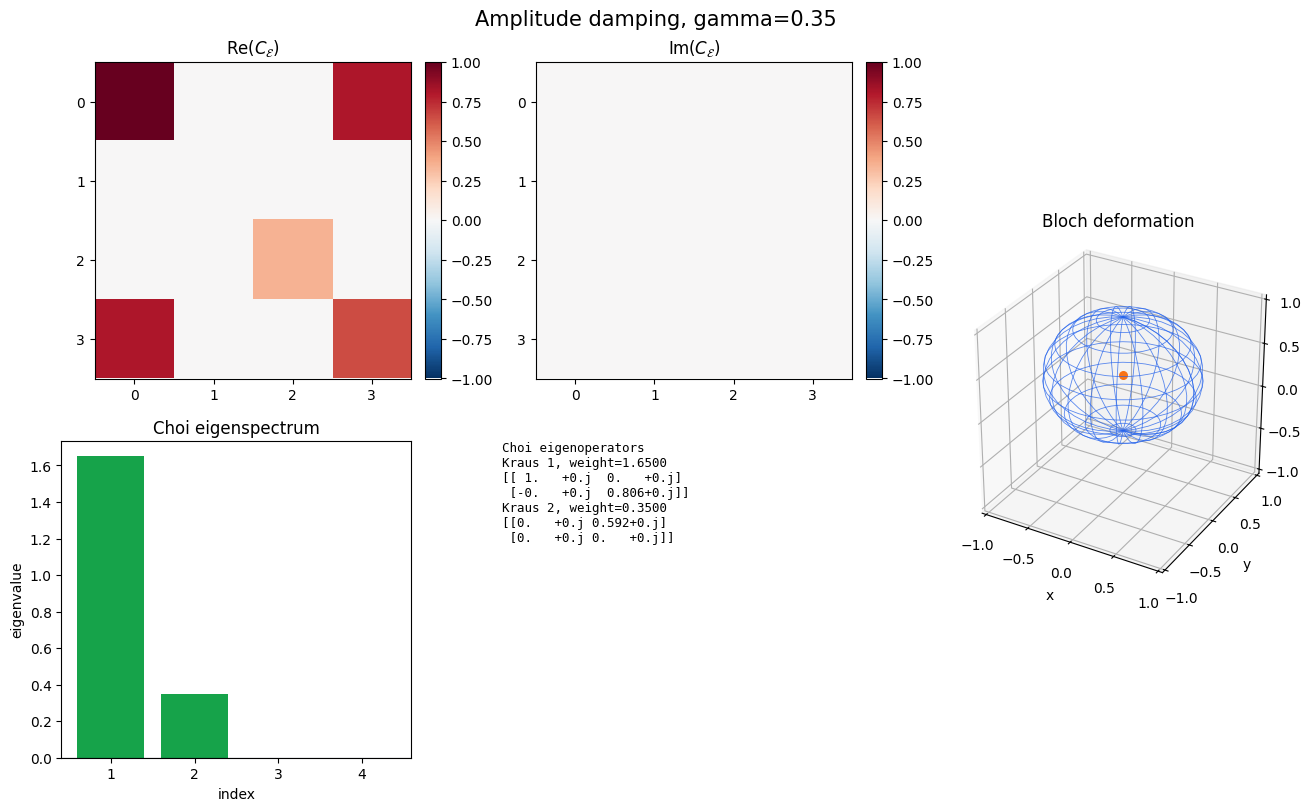

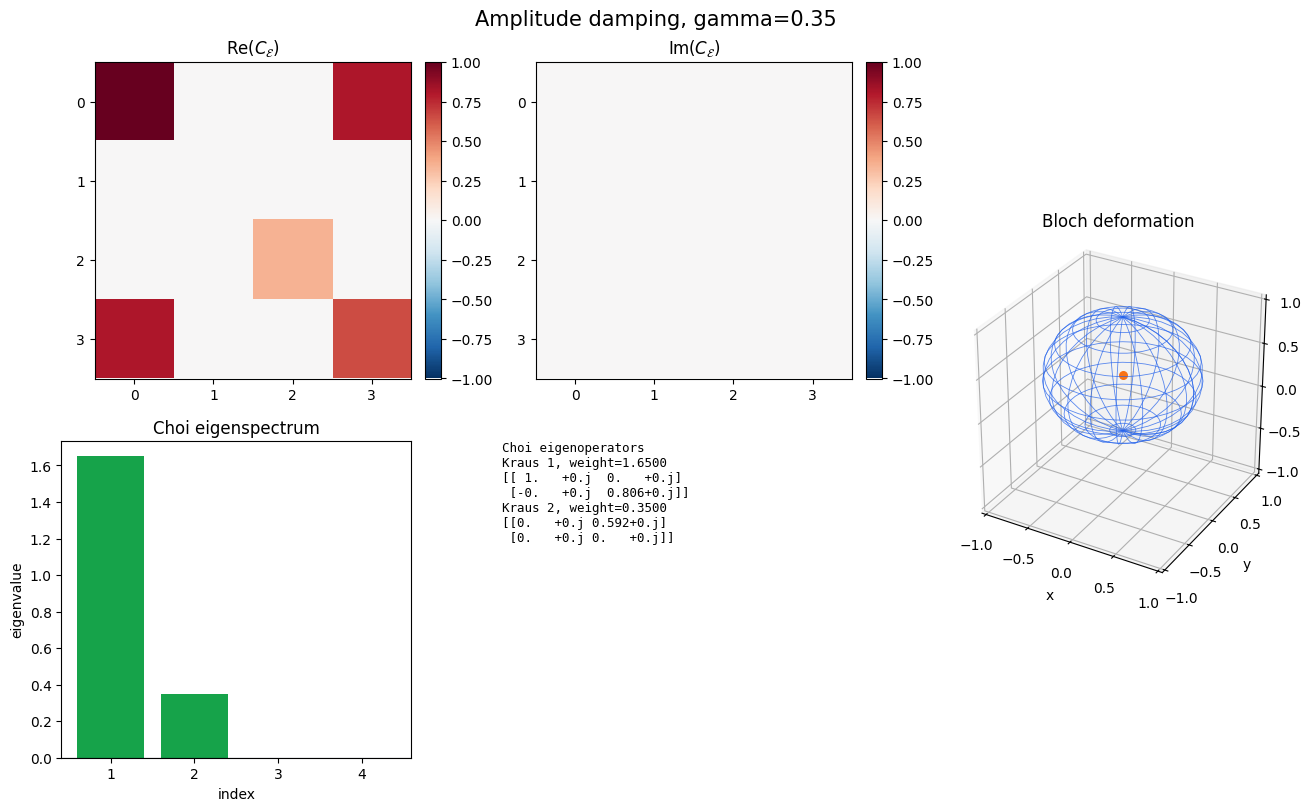

In [3]:
choi = get_channel_choi("Amplitude damping", {"gamma": 0.35})
fig = render_dashboard_figure(choi, "Amplitude damping, gamma=0.35")
fig.savefig("figures/widget_preview.png", dpi=160)
fig

## 5. Indicator Sanity Checks

아래 lightweight checks는 local channel utilities가 표준 physical channel에 대해 CP/TP matrix를 생성하는지 보여 준다. Unital mode는 Bloch scaling factor가 CP tetrahedron을 벗어날 때 의도적으로 non-CP region에 들어갈 수 있다. 이는 왜 $C_{\mathcal{E}} \ge 0$ 조건이 중요한지 가르치기에 유용하다.

In [4]:
examples = {
    "identity": get_channel_choi("Identity", {}),
    "depolarizing p=0.2": get_channel_choi("Depolarizing", {"p": 0.2}),
    "amplitude damping gamma=0.35": get_channel_choi("Amplitude damping", {"gamma": 0.35}),
    "phase damping gamma=0.5": get_channel_choi("Phase damping", {"gamma": 0.5}),
    "pauli px=0.08 py=0.04 pz=0.12": get_channel_choi("Pauli", {"p_x": 0.08, "p_y": 0.04, "p_z": 0.12}),
}

for name, C in examples.items():
    print(name)
    print(format_indicator_text(compute_indicators(C)))
    print()

identity
CP: yes | TP: yes | rank: 1 | Tr(C_E): 2.000000 | min eig: 0.000e+00
TP residual ||Tr_B(C_E)-I_A||: 0.000e+00
F_process(identity): 1.000000 | F_process(depol fit p=0.000): 1.000000

depolarizing p=0.2
CP: yes | TP: yes | rank: 4 | Tr(C_E): 2.000000 | min eig: 1.333e-01
TP residual ||Tr_B(C_E)-I_A||: 1.570e-16
F_process(identity): 0.800000 | F_process(depol fit p=0.200): 0.653333

amplitude damping gamma=0.35
CP: yes | TP: yes | rank: 2 | Tr(C_E): 2.000000 | min eig: -2.751e-16
TP residual ||Tr_B(C_E)-I_A||: 0.000e+00
F_process(identity): 0.815613 | F_process(depol fit p=0.184): 0.676557

phase damping gamma=0.5
CP: yes | TP: yes | rank: 2 | Tr(C_E): 2.000000 | min eig: 0.000e+00
TP residual ||Tr_B(C_E)-I_A||: 3.140e-16
F_process(identity): 0.750000 | F_process(depol fit p=0.250): 0.583333

pauli px=0.08 py=0.04 pz=0.12
CP: yes | TP: yes | rank: 4 | Tr(C_E): 2.000000 | min eig: 8.000e-02
TP residual ||Tr_B(C_E)-I_A||: 1.570e-16
F_process(identity): 0.760000 | F_process(depol fi

## 6. Educational Notes

빠르게 해 볼 만한 실험:

- Depolarizing `p`를 증가시키며 Bloch sphere가 균일하게 수축하고 Choi rank가 증가하는 모습을 관찰한다.
- Amplitude damping `gamma`를 증가시키며 Bloch ellipsoid가 중심에 머무르지 않고 `|0>` 쪽으로 이동하는 모습을 관찰한다.
- Unital `lambda_x`, `lambda_y`, `lambda_z` slider를 CP tetrahedron 밖으로 움직여 TP indicator는 true로 남아 있어도 CP indicator가 fail하는 모습을 확인한다.
- `Mix two channels`를 사용해 CP/TP channel들의 convex mixture가 여전히 CP/TP임을 관찰한다.